### **K-Nearest Neighbors (KNN)**

K-Nearest Neighbors (KNN) is a simple, non-parametric, supervised machine learning algorithm that can be used for both classification and regression tasks. It's often referred to as a 'lazy learner' because it doesn't build a generalized model during the training phase. Instead, it memorizes the training dataset and performs computations only when a prediction is requested.

#### **1. The Core Idea: 'Birds of a Feather Flock Together'**

The fundamental principle behind KNN is that data points that are close to each other in the feature space are likely to have similar labels or values. When you want to classify a new data point (or predict its value):

*   **Find its 'K' nearest neighbors:** Identify the `K` data points in your training set that are closest to the new data point.
*   **Decision based on neighbors:**
    *   **For Classification:** The new data point is assigned the class label that is most common among its `K` nearest neighbors (a majority vote).
    *   **For Regression:** The new data point is assigned the average (or median) value of its `K` nearest neighbors.

#### **2. Key Components of KNN**

##### **a. Choosing 'K' (The Number of Neighbors)**

*   `K` is a critical hyperparameter. Its value directly impacts the model's performance.
*   **Small `K` (e.g., K=1):** The model becomes sensitive to noise and outliers. It can lead to overfitting, as a single noisy neighbor might heavily influence the prediction.
*   **Large `K`:** The model becomes more robust to noise but can blur the boundaries between classes. It might lead to underfitting, as it considers too many neighbors, some of which might be far from the true class/value.
*   **Common practice:** Choose an odd number for `K` (to avoid ties in classification) and use techniques like cross-validation to find the optimal `K` value.

##### **b. Distance Metric (How to Measure 'Closeness')**

To determine the 'nearest' neighbors, KNN needs a way to calculate the distance between data points. Common distance metrics include:

*   **Euclidean Distance:** The most common metric, representing the straight-line distance between two points in Euclidean space. It's suitable for continuous numerical features.
    ```
    d(x, y) = √∑(xi - yi)²
    ```
*   **Manhattan Distance (City Block Distance):** Sum of the absolute differences of their Cartesian coordinates. Useful when features are not independent or when measuring path in a grid.
    ```
    d(x, y) = ∑|xi - yi|
    ```
*   **Minkowski Distance:** A generalization of Euclidean and Manhattan distances.
    ```
    d(x, y) = (∑|xi - yi|^p)^(1/p)
    ```
    (where p=1 for Manhattan, p=2 for Euclidean)
*   **Hamming Distance:** Used for categorical or binary data, counting the number of positions at which the corresponding symbols are different.

##### **c. Feature Scaling**

*   KNN is sensitive to the scale of the features. If one feature has a much larger range of values than others, it will disproportionately influence the distance calculation.
*   It's crucial to perform feature scaling (e.g., standardization or normalization) before applying KNN to ensure all features contribute equally to the distance computation.

#### **3. Steps for Building a KNN Model**

1.  **Load the data:** Get your training dataset with features and target labels/values.
2.  **Choose `K`:** Select the number of neighbors (e.g., K=3, K=5).
3.  **Choose a distance metric:** Decide how to measure distance (e.g., Euclidean).
4.  **Scale features (if necessary):** Apply standardization or normalization.
5.  **For a new data point (during prediction):**
    a.  Calculate the distance from the new data point to all points in the training dataset.
    b.  Sort the distances and identify the `K` closest neighbors.
    c.  **For Classification:** Count the occurrences of each class label among the `K` neighbors and assign the most frequent class.
    d.  **For Regression:** Calculate the average (or median) of the target values of the `K` neighbors and assign it as the prediction.

#### **4. Advantages of KNN**

*   **Simplicity and Interpretability:** Easy to understand and implement.
*   **No Training Phase (Lazy Learner):** No explicit training step, which can be advantageous for frequently updated datasets.
*   **Non-parametric:** Makes no assumptions about the underlying data distribution.
*   **Versatile:** Can be used for both classification and regression tasks.

#### **5. Disadvantages of KNN**

*   **Computationally Expensive (at prediction time):** For large datasets, calculating distances to all training points for each new prediction can be very slow.
*   **Requires High Memory:** Needs to store the entire training dataset.
*   **Sensitive to Outliers and Noise:** Especially with small `K` values.
*   **Curse of Dimensionality:** Performance degrades in high-dimensional spaces because distance metrics become less meaningful (all points tend to be 'far apart').
*   **Sensitive to Feature Scaling:** Requires careful preprocessing.
*   **Difficulty with Imbalanced Data:** A majority class can dominate the 'vote' for `K` neighbors, leading to poor performance on minority classes.

#### **6. Use Cases**

KNN is often used for:

*   **Recommendation Systems:** Finding users with similar preferences.
*   **Image Recognition:** Classifying images based on similar features.
*   **Anomaly Detection:** Identifying data points that are significantly different from their neighbors.
*   **Medical Diagnosis:** Classifying diseases based on patient symptoms.

In summary, KNN is a powerful and intuitive algorithm, particularly effective for smaller datasets and when the decision boundary is complex or non-linear. However, its efficiency and accuracy can be significantly impacted by the dataset size, dimensionality, and the chosen hyperparameters (`K` and distance metric).

### **K-Nearest Neighbors (KNN) for Regression**

While K-Nearest Neighbors (KNN) is often discussed in the context of classification, it can also be effectively used for **regression tasks**. The fundamental principle remains the same – finding the `K` nearest data points – but the method of making a prediction changes.

#### **How KNN Regression Works**

For a given new data point whose continuous target value we want to predict, KNN Regression follows these steps:

1.  **Select K:** Choose the number of neighbors (`K`). As with classification, this is a crucial hyperparameter.
2.  **Calculate Distances:** Compute the distance (e.g., Euclidean, Manhattan) from the new data point to all existing data points in the training dataset. Feature scaling is equally important here.
3.  **Identify K Nearest Neighbors:** Select the `K` data points from the training set that have the smallest distances to the new data point.
4.  **Predict the Output Value:** Instead of taking a majority vote (as in classification), KNN regression predicts the output as the **average (mean)** or **median** of the target values of these `K` nearest neighbors.

    *   **Mean:** The most common approach. It averages the continuous target values of the `K` neighbors.
        `y_predicted = (1/K) * Σ (y_i for i in K_neighbors)`
    *   **Median:** Can be more robust to outliers than the mean, as it is less affected by extreme values among the neighbors.

#### **Weighted KNN Regression**

A common enhancement to basic KNN regression is **weighted KNN**. In this approach, instead of simply averaging the target values, a weighted average is used. The weights are typically inversely proportional to the distance of each neighbor from the new data point.

*   **Closer neighbors have a greater influence** on the prediction, while further neighbors have less influence.
*   A common weighting scheme uses `1/distance` or `1/distance^2` as the weight.

    `y_predicted = (Σ (w_i * y_i) for i in K_neighbors) / (Σ w_i for i in K_neighbors)`
    where `w_i` is the weight for neighbor `i` (e.g., `1/distance_i`).

#### **Key Considerations for KNN Regression**

*   **Choice of K:** Still the most important hyperparameter. A small `K` can lead to high variance (sensitive to individual neighbors), while a large `K` can lead to high bias (predictions might be too smoothed out and miss local patterns).
*   **Distance Metric:** The choice of distance metric (Euclidean, Manhattan, etc.) can impact results, especially with different feature types.
*   **Feature Scaling:** Essential for KNN regression, just as it is for classification, to ensure all features contribute fairly to the distance calculations.
*   **Dimensionality:** KNN performance degrades in high-dimensional spaces (Curse of Dimensionality) because the concept of 'nearest' becomes less meaningful, and data points tend to be sparse.
*   **Computational Cost:** Can be high for large datasets at prediction time, as distances need to be calculated for each new query point.
*   **Memory Usage:** Stores the entire training dataset.

#### **Advantages specific to Regression**

*   **No parametric assumptions:** Doesn't assume a linear relationship between features and target, making it flexible for non-linear problems.
*   **Local approximation:** Makes predictions based on local patterns in the data, which can be useful when relationships vary across the feature space.

#### **Disadvantages specific to Regression**

*   **Limited Extrapolation:** KNN regression cannot predict values outside the range of the target values observed in its `K` nearest neighbors. If all nearest neighbors have target values between 10 and 20, the prediction will also be in that range, even if the true value for a new point could be 30.
*   **Sensitivity to Irrelevant Features:** Features that are not relevant to the target variable can still influence distance calculations, potentially leading to poor predictions if not handled.

In essence, KNN Regression is a simple yet powerful non-parametric method for predicting continuous values, relying on the 'wisdom' of its closest neighbors. It's often a good baseline model and can perform well on datasets where local patterns are important and the number of features is not excessively large.

# Program 1: Basic KNN Regression on Synthetic Dataset

In [65]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

# Create dataset
X, y = make_regression(
    n_samples=200,
    n_features=1,
    noise=20,
    random_state=42
)

In [66]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [67]:
model=KNeighborsRegressor(n_neighbors=5)
model.fit(X_train,y_train)

KNeighborsRegressor()

R2 Score: 0.9171397334491227


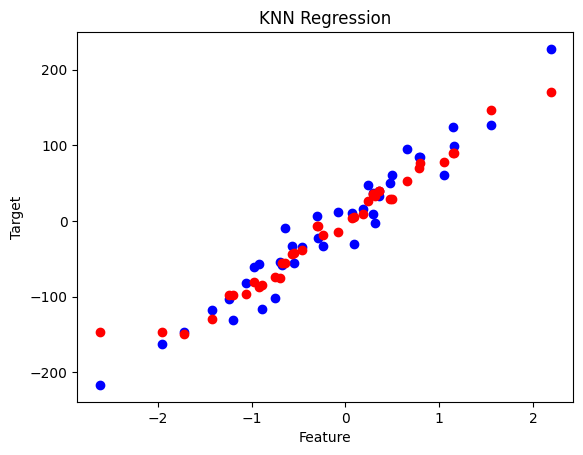

In [68]:
pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))

# Plot
plt.scatter(X_test, y_test, color="blue")
plt.scatter(X_test, pred, color="red")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("KNN Regression")
plt.show()

# Program 2: KNN Regression with Feature Scaling

In [69]:
import numpy as np

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

In [70]:
X,y=make_regression(
    n_samples=300,
    n_features=2,
    n_informative=2,
    noise=10,
    random_state=42

)

In [71]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [72]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [73]:
model=KNeighborsRegressor(n_neighbors=5)

model.fit(X_train,y_train)

print(model.score(X_test,y_test))

0.9353902142782263


# Program 3:Compare Uniform vs Distance Weights

In [74]:
import numpy as np

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

X,y=make_regression(
n_samples=300,
n_features=1,
noise=25,
random_state=42
)

In [75]:
X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2
)


In [76]:
uniform=KNeighborsRegressor(
n_neighbors=5,
weights='uniform'
)

In [77]:
distance=KNeighborsRegressor(
n_neighbors=5,
weights='distance'
)

In [78]:
uniform.fit(X_train,y_train)
distance.fit(X_train,y_train)

print("Uniform:",uniform.score(X_test,y_test))
print("Distance:",distance.score(X_test,y_test))

Uniform: 0.4676321435791052
Distance: 0.37195718525529886


#Program 4: House Price Prediction

In [79]:
from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsRegressor

housing=fetch_california_housing()

X=housing.data
y=housing.target

X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42
)

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

model=KNeighborsRegressor(
n_neighbors=8
)

model.fit(X_train,y_train)

print("R2:",model.score(X_test,y_test))

R2: 0.6760198206555295


In [80]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
mean_absolute_error,
mean_squared_error,
r2_score
)

In [81]:
X,y=make_regression(
n_samples=500,
n_features=2,
noise=15,
random_state=42
)

In [82]:
X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42
)

In [83]:
sacler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [84]:

model.fit(X_train,y_train)

pred=model.predict(X_test)

MAE : 11.464419969250395
MSE : 210.2563854200929
RMSE: 14.500220185227978
R2  : 0.6122284161951059


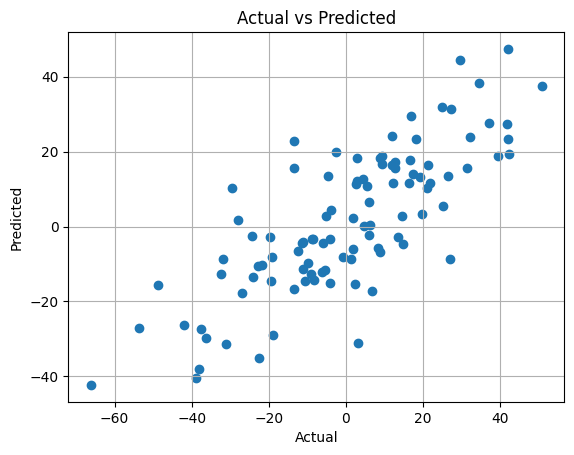

In [85]:
print("MAE :",mean_absolute_error(y_test,pred))
print("MSE :",mean_squared_error(y_test,pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred)))
print("R2  :",r2_score(y_test,pred))

plt.scatter(y_test,pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

# Program 5:Student Marks Prediction

In [86]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 1000

study_hours = np.random.randint(1, 12, n)
attendance = np.random.randint(50, 101, n)
assignments = np.random.randint(40, 101, n)

marks = (
    study_hours * 5
    + attendance * 0.3
    + assignments * 0.2
    + np.random.normal(0, 5, n)
)

df = pd.DataFrame({
    "Study_Hours": study_hours,
    "Attendance": attendance,
    "Assignments": assignments,
    "Marks": marks
})

print(df.head())

   Study_Hours  Attendance  Assignments      Marks
0            7          88           57  72.107720
1            4          89           79  56.378509
2           11          63           60  84.854884
3            8          81           54  70.847398
4            5         100           72  66.497383


In [87]:
X = df[['Study_Hours','Attendance','Assignments']]

y = df['Marks']

In [88]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [89]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

In [90]:
from sklearn.neighbors import KNeighborsRegressor

model=KNeighborsRegressor(
n_neighbors=3
)

model.fit(X_train,y_train)

KNeighborsRegressor(n_neighbors=3)

In [91]:
pred=model.predict(X_test)

In [92]:
from sklearn.metrics import (
mean_absolute_error,
mean_squared_error,
r2_score
)

import numpy as np

print("MAE :",mean_absolute_error(y_test,pred))

print("MSE :",mean_squared_error(y_test,pred))

print("RMSE:",np.sqrt(mean_squared_error(y_test,pred)))

print("R2 :",r2_score(y_test,pred))

MAE : 4.507377808868247
MSE : 32.383603225231006
RMSE: 5.690659296182737
R2 : 0.9024447516376249


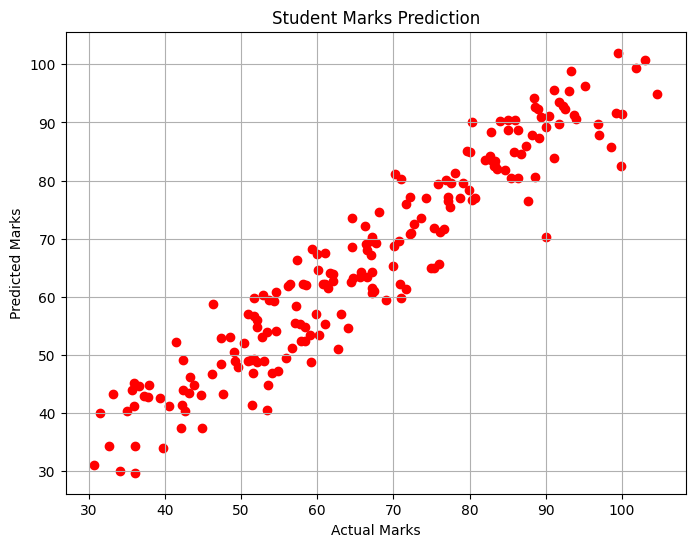

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test,pred,color='red')

plt.xlabel("Actual Marks")

plt.ylabel("Predicted Marks")

plt.title("Student Marks Prediction")

plt.grid(True)

plt.show()

In [94]:
new_student = [[8,90,88]]

new_student = scaler.transform(new_student)

prediction = model.predict(new_student)

print("Predicted Marks:",prediction[0])

Predicted Marks: 77.08612630186035


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Iris Flower Classification

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
iris=load_iris()

In [3]:
X=iris.data[:,:2]
y=iris.target

In [4]:
X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42
)

In [5]:
model=SVC(kernel='linear')
model.fit(X_train,y_train)

SVC(kernel='linear')

In [6]:
y_pred=model.predict(X_test)

In [8]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.9


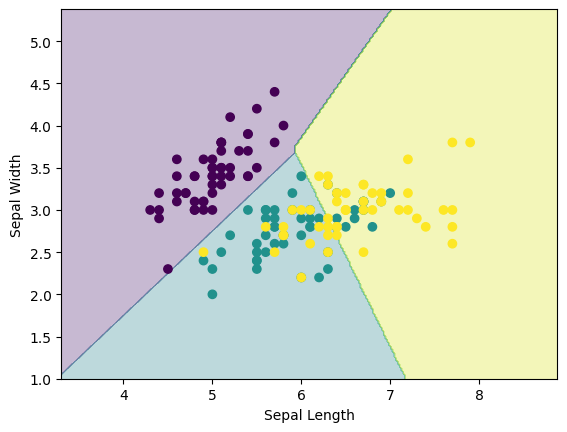

In [9]:
# Visualization
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X[:,0], X[:,1], c=y)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()

# Wine Classification

In [10]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score



In [11]:
wine=load_wine()

In [12]:

X = wine.data
y = wine.target

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
X,y,test_size=0.2,random_state=42)


In [14]:
scaler=StandardScaler()

In [15]:
X_train_scaled=scaler.fit_transform(X_train)
y_train_scaled=scaler.transform(X_test)

In [16]:
model = SVC(kernel="poly", degree=3)

model.fit(X_train,y_train)

pred=model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.8333333333333334


# Email Spam Classificat

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

texts=[
"Win money now",
"Meeting at 5 PM",
"Claim your reward",
"Project submission",
"Lottery Winner",
"Let's study together",
"Cheap loans available",
"Birthday Party"
]

labels=[1,0,1,0,1,0,1,0]

In [18]:
vectorizer=TfidfVectorizer()
X=vectorizer.fit_transform(texts)

In [19]:
X_train,X_test,y_train,y_test=train_test_split(
X,labels,test_size=0.2,random_state=42
)

In [20]:
model=LinearSVC()
model.fit(X_train,y_train)
pred=model.predict(X_test)

In [21]:
print("Accuracy:",accuracy_score(y_test,pred))

new_text=["Congratulations You won lottery"]

new_vec=vectorizer.transform(new_text)

print(model.predict(new_vec))

Accuracy: 0.0
[1]
